In [1]:
import numpy as np
import pandas as pd

In [2]:
from utils import plot

nect_df = pd.read_csv('datas/nect_honey_price.csv')
island_df = pd.read_csv('datas/island_data.csv')

nect_price = nect_df['price'].values
nav = island_df['nav'].values
volatile_part = island_df['wbtc_frac'].values

timestamp = nect_df['timestamp'].values

SCALE = 6.5*10**7
nav = nav/SCALE

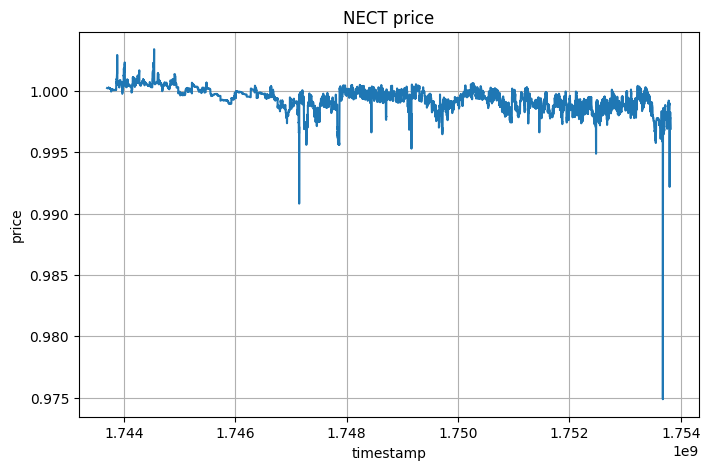

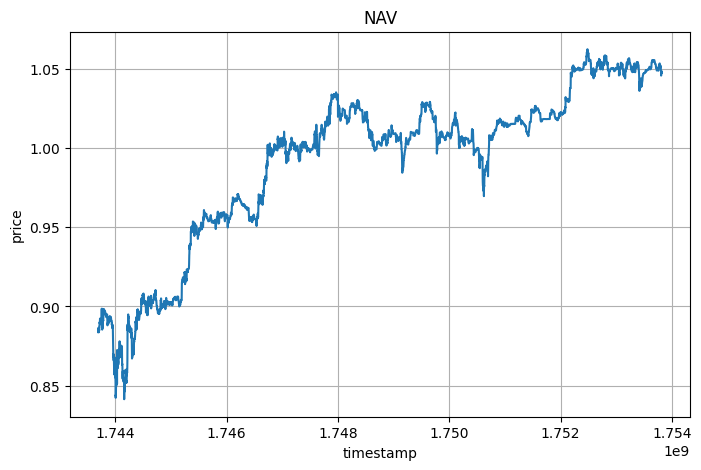

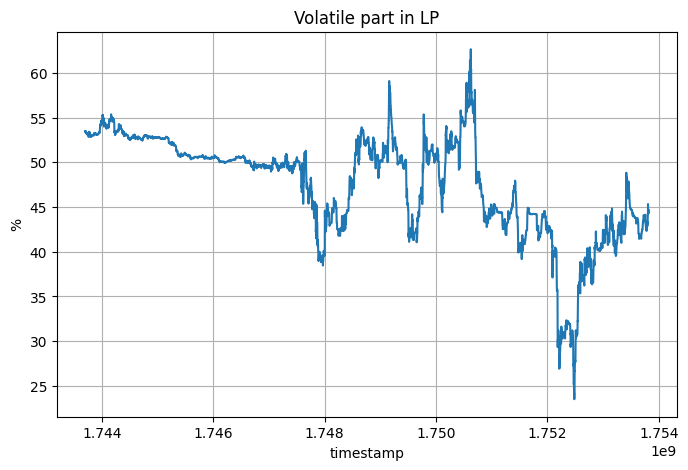

In [3]:
plot(
    timestamp,
    nect_price,
    'timestamp',
    'price',
    'NECT price'
)

plot(
    timestamp,
    nav,
    'timestamp',
    'price',
    'NAV'
)

plot(
    timestamp,
    volatile_part*100,
    'timestamp',
    '%',
    'Volatile part in LP'
)

In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from special_functions import plateau, deltaFunctionBarier, plateauFlat
import random

class rawDLVEnv(gym.Env):
    def __init__(
            self,
            nect_honey_price,
            LP_nav_honey,
            volatile_part,
            init_LP = 1,
            max_step = 0.15,
            target_leverage = 2,
            min_cr = 1.2,
            is_training = False,
            spread = 0.005,
            impact_coeff = 0.0005,
            primordial_action_penalty = 0.6,
            penalty_damping = 0.9,
            action_penalty_scale = 0.03,
            liquidation_penalty_scale = 1/40
        ):
        
        super(rawDLVEnv, self).__init__()

        self.nect_price = nect_honey_price
        self.nav = LP_nav_honey/nect_honey_price # nav in terms of nect
        self.volatile_part = volatile_part # % of the volatile token (wbtc) in the LP token
        self.num_of_liquidations = 0
        self.max_steps = len(self.nav)
        self.target_leverage = target_leverage
        self.starting_LP = init_LP
        self.max_action = max_step
        self.min_cr = min_cr
        self.is_training = is_training
        self.spread = spread
        self.impact_coeff = impact_coeff
        self.primordial_action_penalty = primordial_action_penalty
        self.action_penalty_damping = penalty_damping 
        self.action_penalty_scale = action_penalty_scale
        self.liquidation_penalty_scale = liquidation_penalty_scale

        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.LP = self.starting_LP
        self.collateral_value = self.LP*self.nav[0]
        self.volatile_part_value = self.collateral_value*self.volatile_part[0]
        if self.is_training:
            self.nect = (self.collateral_value - self.volatile_part_value)*(self.target_leverage - 1)
            self.nect = random.uniform(0.1, 3*self.nect)
        else:
            self.nect = (self.collateral_value - self.volatile_part_value)*(self.target_leverage - 1)
        self.leverage_margin = self.nect/(self.collateral_value - self.volatile_part_value) + 1 - self.target_leverage
        self.cr_margin = self.collateral_value/self.nect - self.min_cr
        self.LP_margin = self.LP/self.starting_LP

        self.nect_gain_margin = 0
        self.lp_gain_margin = 0
        self.collateral_value_gain_margin = 0
        self.volatile_part_value_gain_margin = 0
        self.leverage_gain_margin = 0
        self.cr_margin_gain_margin = 0
        self.prev_action_cost = 0
        self.current_action_penalty = 0 

        self.history = {
            'NECT': [],
            'collateral value': [],
            'volatile value': [],
            'reward': [],
            'leverage': [],
            'collaterization ratio': [],
            'LP': []
        }

        obs = self._get_obs()
        info = {}
        return obs, info

    def _get_obs(self):
        return np.array([
            self.nect,
            self.collateral_value,
            self.volatile_part_value,
            self.leverage_margin,
            self.cr_margin,
            self.LP_margin,
            self.nect_gain_margin,
            self.lp_gain_margin,
            self.collateral_value_gain_margin,
            self.volatile_part_value_gain_margin,
            self.leverage_gain_margin,
            self.cr_margin_gain_margin
        ], dtype=np.float32)
    
    def _compute_transaction_cost(self, action_size):
        return abs(action_size)*self.spread + self.impact_coeff * (action_size ** 2)

    def step(self, action):
        action_size = float(action[0])*self.max_action
        action_penalty = self.current_action_penalty + self.primordial_action_penalty
        
        if float(action[1]) > 0:
            action_size = 0
            action_penalty = 0
            self.current_action_penalty = self.current_action_penalty*self.action_penalty_damping

        cost = self._compute_transaction_cost(action_size)
        self.prev_action_cost = cost
        
        current_nav = self.nav[self.step_count]
        nect_price = self.nect_price[self.step_count]

        nect = max(self.nect + action_size, 0)
        self.nect_gain_margin = min(nect/(self.nect + 1e-10) - 1, 10)
        self.nect = nect

        lp = self.LP - cost/current_nav
        self.lp_gain_margin = lp/(self.LP + 1e-10) - 1
        self.LP = lp
        self.LP_margin = self.LP/self.starting_LP

        if action_penalty!=0:
            action_penalty = action_penalty + 150*cost/current_nav
            self.current_action_penalty = action_penalty
        
        collateral_value = current_nav*self.LP
        self.collateral_value_gain_margin = collateral_value/(self.collateral_value + 1e-10) - 1
        self.collateral_value = collateral_value

        volatile_part_value = self.volatile_part[self.step_count]*self.collateral_value
        self.volatile_part_value_gain_margin = volatile_part_value/(self.volatile_part_value + 1e-10) - 1
        self.volatile_part_value = volatile_part_value

        leverage = self.nect/(self.collateral_value - self.volatile_part_value + 1e-10) + 1 
        self.leverage_gain_margin = leverage/(self.leverage_margin + self.target_leverage + 1e-10) - 1
        self.leverage_margin = leverage - self.target_leverage

        cr_margin = self.collateral_value/(self.nect + 1e-8) - self.min_cr
        self.cr_margin_gain_margin = cr_margin/self.cr_margin - 1
        self.cr_margin = cr_margin
        if self.cr_margin <= 0:
            self.num_of_liquidations += 1
            liquidation_penalty = deltaFunctionBarier(0) 
            if self.is_training:
                terminated = False
                truncated = self.step_count >= self.max_steps - 1
            else:
                terminated = True
                truncated = True
        else:
            liquidation_penalty = deltaFunctionBarier(self.cr_margin)
            terminated = False
            truncated = self.step_count >= self.max_steps - 1

        leverage_reward = 1/2*(plateau(self.leverage_margin) + plateauFlat(self.leverage_margin))
        reward = leverage_reward - liquidation_penalty*self.liquidation_penalty_scale - action_penalty*self.action_penalty_scale

        self.history['NECT'].append(self.nect)
        self.history['collateral value'].append(self.collateral_value*nect_price)
        self.history['volatile value'].append(self.volatile_part_value*nect_price)
        self.history['leverage'].append(self.target_leverage + self.leverage_margin)
        self.history['reward'].append(reward)
        self.history['collaterization ratio'].append(self.cr_margin + self.min_cr)
        self.history['LP'].append(self.LP)

        obs = self._get_obs()
        self.step_count += 1
        info = {}

        return obs, reward, terminated, truncated, info
    
    def get_history(self):
        return self.history, self.num_of_liquidations

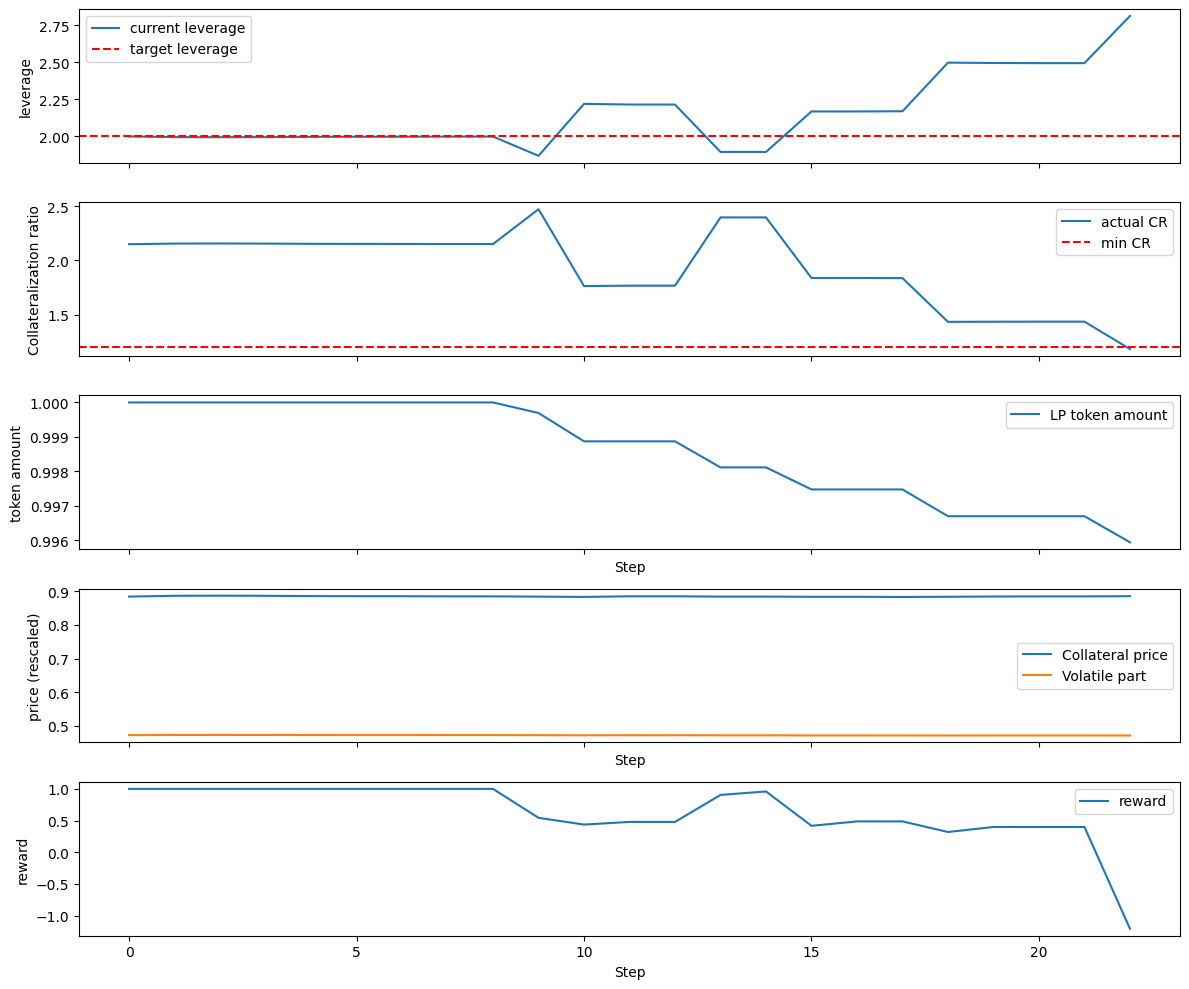

In [5]:
from utils import plot_training_metrics
#from raw_env import rawDLVEnv

env = rawDLVEnv(nect_honey_price=nect_price, LP_nav_honey=nav, volatile_part=volatile_part)

done = False
while not done:
    action = env.action_space.sample()  # Random action
    obs, reward, _, done, _ = env.step(action)

plot_training_metrics(env.history)

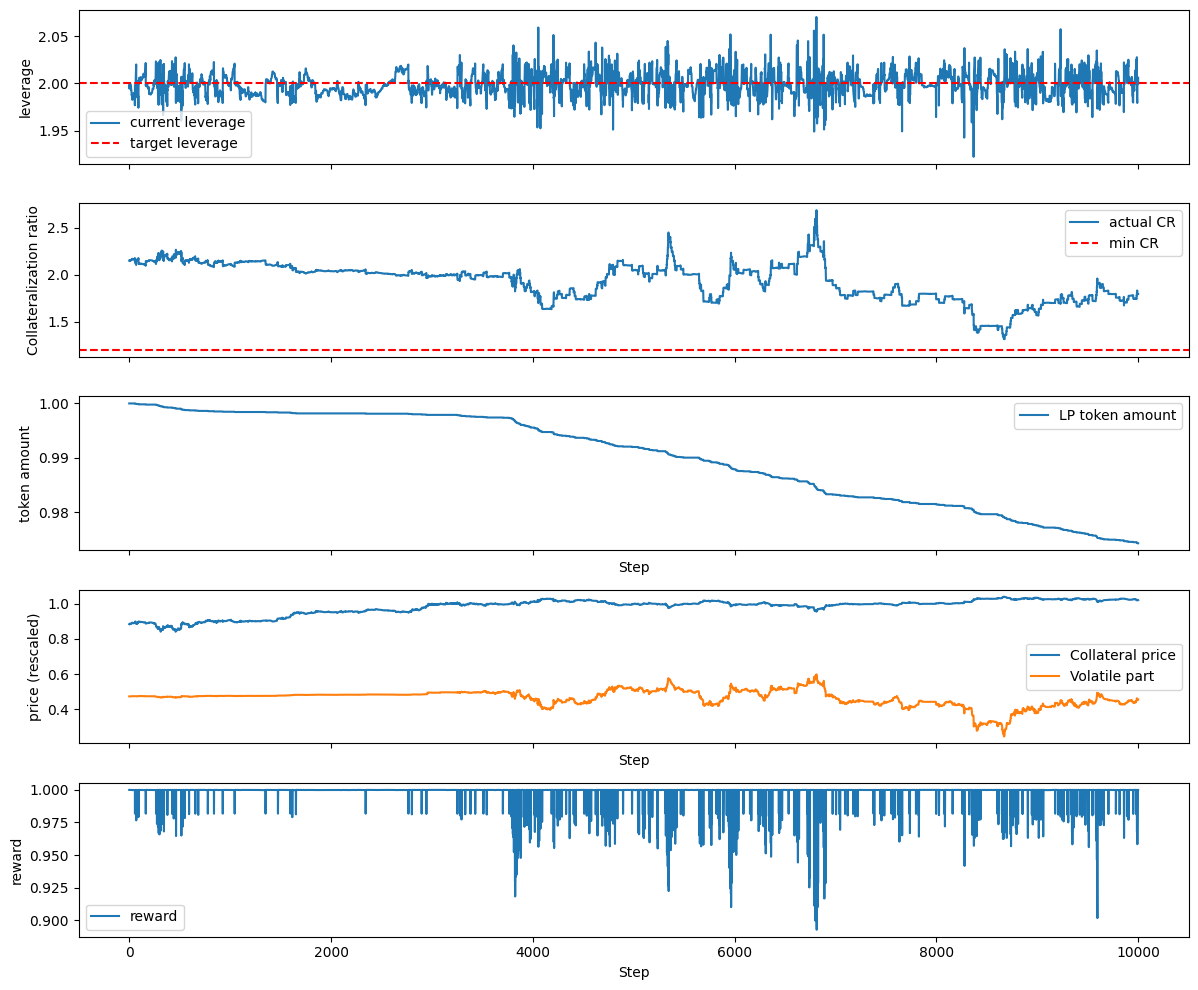

In [6]:
def naiveAgent(obs, target_leverage = 2, max_step = 0.15):

    nect = obs[0]
    leverage = obs[3]+2
    colateral_value = obs[1]
    volatile_part_value = obs[2]

    if abs(leverage - target_leverage)/target_leverage<=0.01:
        return [0,1]
    else: 
        nect_target = (target_leverage - 1)*(colateral_value - volatile_part_value)
        return [(nect_target-nect)/max_step,0]

env = rawDLVEnv(nect_honey_price=nect_price, LP_nav_honey=nav, volatile_part=volatile_part)

obs, _ = env.reset()

done = False
while not done:
    action = naiveAgent(obs) 
    obs, reward, _, done, _ = env.step(action)

agent_history = env.history
plot_training_metrics(agent_history)

In [7]:
from stable_baselines3 import PPO
import random
import torch
from stable_baselines3.common.utils import get_linear_fn

SEED = 400
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

train_env = rawDLVEnv(
    nect_honey_price=nect_price, 
    LP_nav_honey=nav, 
    volatile_part=volatile_part,
    is_training=True
)

model = PPO(
    "MlpPolicy", 
    train_env, 
    verbose=1
)
model.learn(total_timesteps=300000)
#model.save("ppo_leverage_historical")

_, num_of_liquidation = train_env.get_history()
print('Liquidations during learnings:', num_of_liquidation)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 2937 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1868         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0052328426 |
|    clip_fraction        | 0.0418       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | -0.0447      |
|    learning_rate        | 0.0003       |
|    loss                 | 61.9         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00561     |
|    std

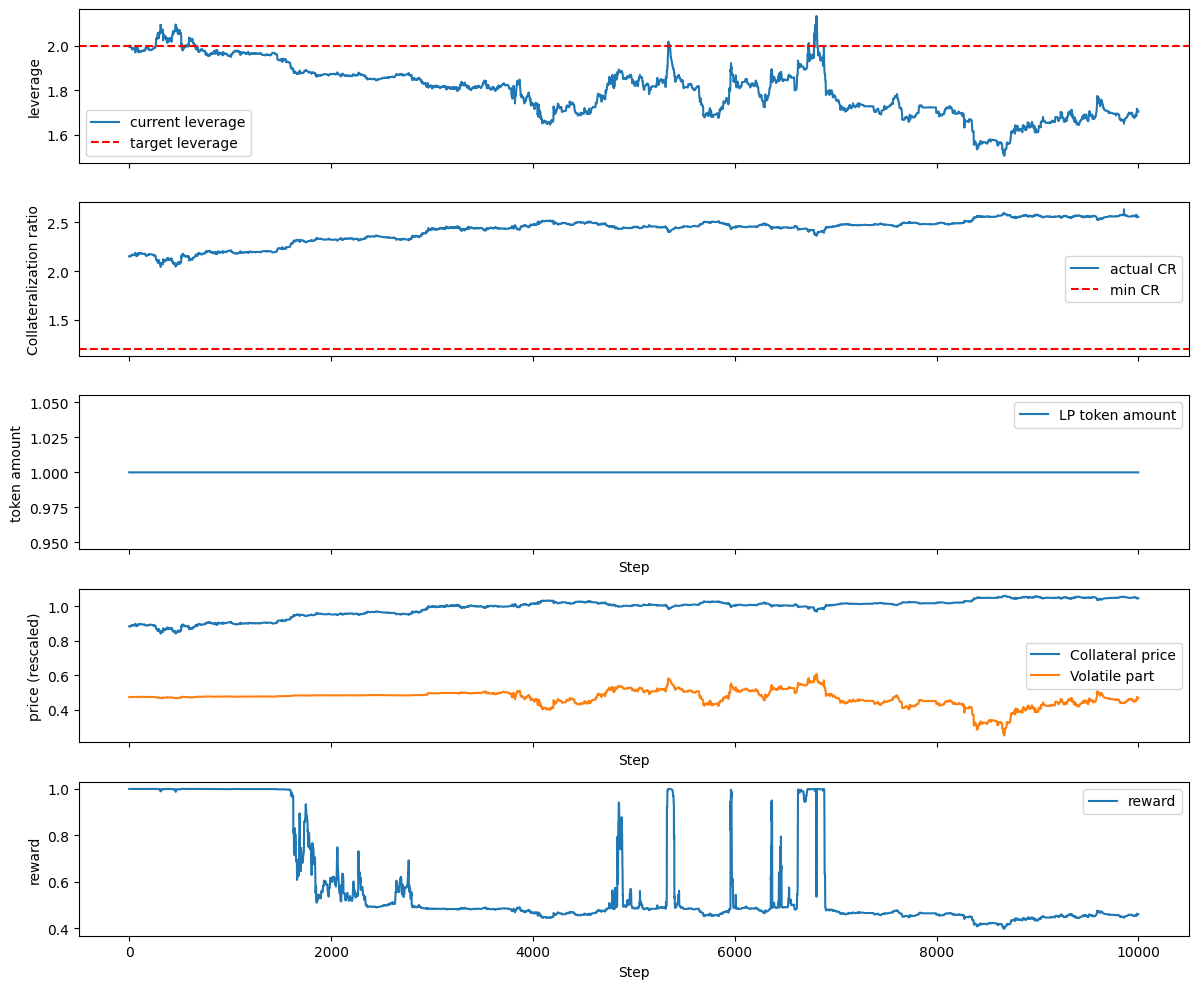

In [8]:
eval_env = rawDLVEnv(
    nect_honey_price=nect_price, 
    LP_nav_honey=nav, 
    volatile_part=volatile_part
)

obs, _ = eval_env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, _, done, _ = eval_env.step(action)

history, _ = eval_env.get_history()
plot_training_metrics(history)

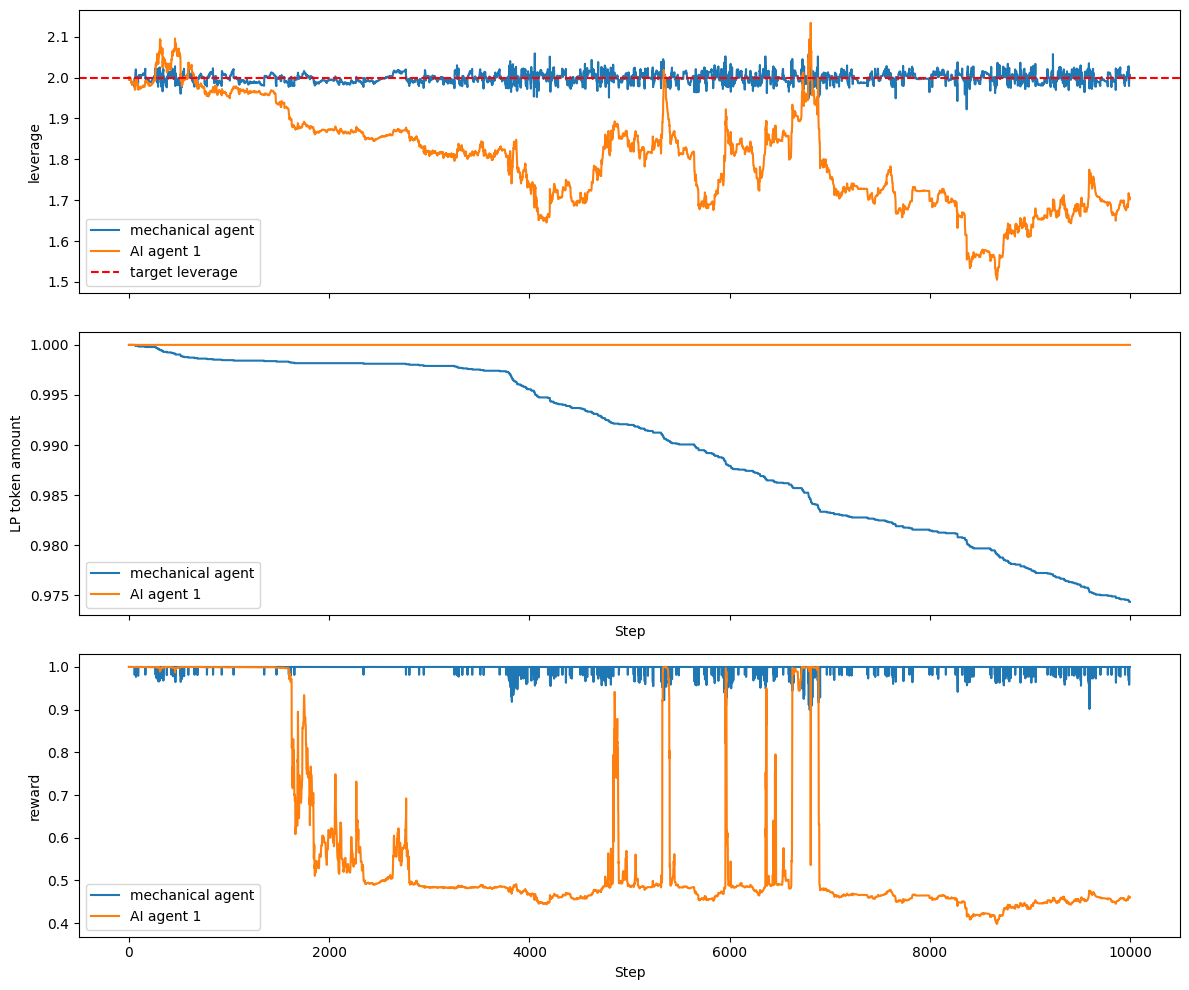

In [9]:
from utils import plot_training_comparison

plot_training_comparison(agent_history, [history])